# EDA-07 · Van Hanh & Chat Luong Dich Vu (Operations & Service Quality)
**Order Fulfilment & SLA** · **Return Analysis (margin erosion)** · **Inventory Health + Rating Correlation** · **Customer Satisfaction**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,
                     'grid.alpha':0.3,'font.size':10})

orders  = pd.read_csv('orders.csv',      parse_dates=['order_date'])
ships   = pd.read_csv('shipments.csv',   parse_dates=['ship_date','delivery_date'])
rets    = pd.read_csv('returns.csv',     parse_dates=['return_date'])
reviews = pd.read_csv('reviews.csv',     parse_dates=['review_date'])
inv     = pd.read_csv('inventory.csv',   parse_dates=['snapshot_date'])
items   = pd.read_csv('order_items.csv', low_memory=False)
prods   = pd.read_csv('products.csv')
pays    = pd.read_csv('payments.csv')

# Revenue per order
order_rev = (items.assign(rev_line=items['quantity']*items['unit_price'])
             .groupby('order_id')['rev_line'].sum().reset_index()
             .rename(columns={'rev_line':'revenue'}))

# Fulfilment times
ships['transit_days']  = (ships['delivery_date'] - ships['ship_date']).dt.days
ships_ord = ships.merge(orders[['order_id','order_date']], on='order_id', how='left')
ships_ord['process_days'] = (ships_ord['ship_date']  - ships_ord['order_date']).dt.days
ships_ord['fulfil_days']  = (ships_ord['delivery_date'] - ships_ord['order_date']).dt.days
ships_ord['year']  = ships_ord['order_date'].dt.year
ships_ord['month'] = ships_ord['order_date'].dt.month
ships_ord['dow']   = ships_ord['order_date'].dt.dayofweek

# SLA: fulfil_days > 7 = breach
SLA_LIMIT = 7
ships_ord['sla_breach'] = ships_ord['fulfil_days'] > SLA_LIMIT

# Reviews enriched
reviews['year']  = reviews['review_date'].dt.year
reviews['month'] = reviews['review_date'].dt.month
reviews = reviews.merge(prods[['product_id','category','segment']], on='product_id', how='left')

# Returns enriched
rets_full = rets.merge(orders[['order_id','order_date','order_status']], on='order_id', how='left')
rets_full['year']  = rets_full['order_date'].dt.year
rets_full = rets_full.merge(prods[['product_id','category']], on='product_id', how='left')
rets_full = rets_full.merge(pays[['order_id','payment_value']], on='order_id', how='left')
rets_full['refund_gt_payment'] = rets_full['refund_amount'] > rets_full['payment_value']

print(f'Shipments  : {len(ships):,}  (transit {ships["transit_days"].min()}-{ships["transit_days"].max()} days)')
print(f'Returns    : {len(rets):,}  reasons: {rets["return_reason"].unique().tolist()}')
print(f'Reviews    : {len(reviews):,}  rating avg={reviews["rating"].mean():.2f}')
print(f'Inventory  : {len(inv):,}  snapshots  ({inv["snapshot_date"].min().date()} - {inv["snapshot_date"].max().date()})')
print(f'SLA limit  : {SLA_LIMIT} days (order -> delivery)')
print(f'SLA breach : {ships_ord["sla_breach"].sum():,} ({ships_ord["sla_breach"].mean()*100:.2f}%)')


Shipments  : 566,067  (transit 2-7 days)
Returns    : 39,939  reasons: ['late_delivery', 'wrong_size', 'defective', 'changed_mind', 'not_as_described']
Reviews    : 113,551  rating avg=3.94
Inventory  : 60,247  snapshots  (2012-07-31 - 2022-12-31)
SLA limit  : 7 days (order -> delivery)
SLA breach : 141,050 (24.92%)


## Part 1 · Order Fulfilment & SLA Breach Rate
> SLA defined as: total fulfillment time (order_date → delivery_date) ≤ 7 days.  
> Transit days (ship → delivery) luon trong khoang 2–7 ngay (khong co breach).  
> Processing time (order → ship) moi la nguon bien dong.

In [2]:
print('=== Fulfilment Time Distribution ===')
for col, label in [('process_days','Process (order->ship)'),
                   ('transit_days', 'Transit (ship->delivery)'),
                   ('fulfil_days',  'Total (order->delivery)')]:
    s = ships_ord[col]
    print(f'{label:28s}: mean={s.mean():.1f}d  median={s.median():.0f}d  '
          f'p90={s.quantile(.9):.0f}d  max={s.max():.0f}d')
print()

# Order status breakdown
status_cnt = orders['order_status'].value_counts()
status_pct = status_cnt / len(orders) * 100
print('=== Order Status Breakdown ===')
for st, cnt in status_cnt.items():
    print(f'  {st:12s}: {cnt:>7,}  ({status_pct[st]:.2f}%)')
print()

# Stuck orders: not delivered, not returned, not cancelled
stuck_statuses = ['shipped','paid','created']
stuck = orders[orders['order_status'].isin(stuck_statuses)]
print(f'Stuck orders (shipped/paid/created - chua co ket qua): {len(stuck):,}  ({len(stuck)/len(orders)*100:.2f}%)')
print()

# SLA breach by year
breach_yr = ships_ord.groupby('year').agg(
    n_orders    = ('order_id','count'),
    n_breach    = ('sla_breach','sum'),
    avg_fulfil  = ('fulfil_days','mean'),
    pct_breach  = ('sla_breach','mean'),
).reset_index()
breach_yr['pct_breach'] *= 100
print('=== SLA Breach by Year ===')
print(breach_yr[['year','n_orders','n_breach','pct_breach','avg_fulfil']].to_string(index=False))


=== Fulfilment Time Distribution ===
Process (order->ship)       : mean=1.5d  median=1d  p90=3d  max=3d
Transit (ship->delivery)    : mean=4.5d  median=4d  p90=7d  max=7d
Total (order->delivery)     : mean=6.0d  median=6d  p90=9d  max=10d

=== Order Status Breakdown ===
  delivered   : 516,716  (79.87%)
  cancelled   :  59,462  (9.19%)
  returned    :  36,142  (5.59%)
  shipped     :  13,773  (2.13%)
  paid        :  13,577  (2.10%)
  created     :   7,275  (1.12%)

Stuck orders (shipped/paid/created - chua co ket qua): 34,625  (5.35%)

=== SLA Breach by Year ===
 year  n_orders  n_breach  pct_breach  avg_fulfil
 2012     28146      7067   25.108364    6.012790
 2013     67390     16854   25.009645    5.999866
 2014     70844     17514   24.721924    5.980817
 2015     72456     18008   24.853704    5.997295
 2016     72390     18101   25.004835    6.002155
 2017     66943     16577   24.762858    5.995489
 2018     60966     15325   25.136962    6.003543
 2019     36431      9104   24

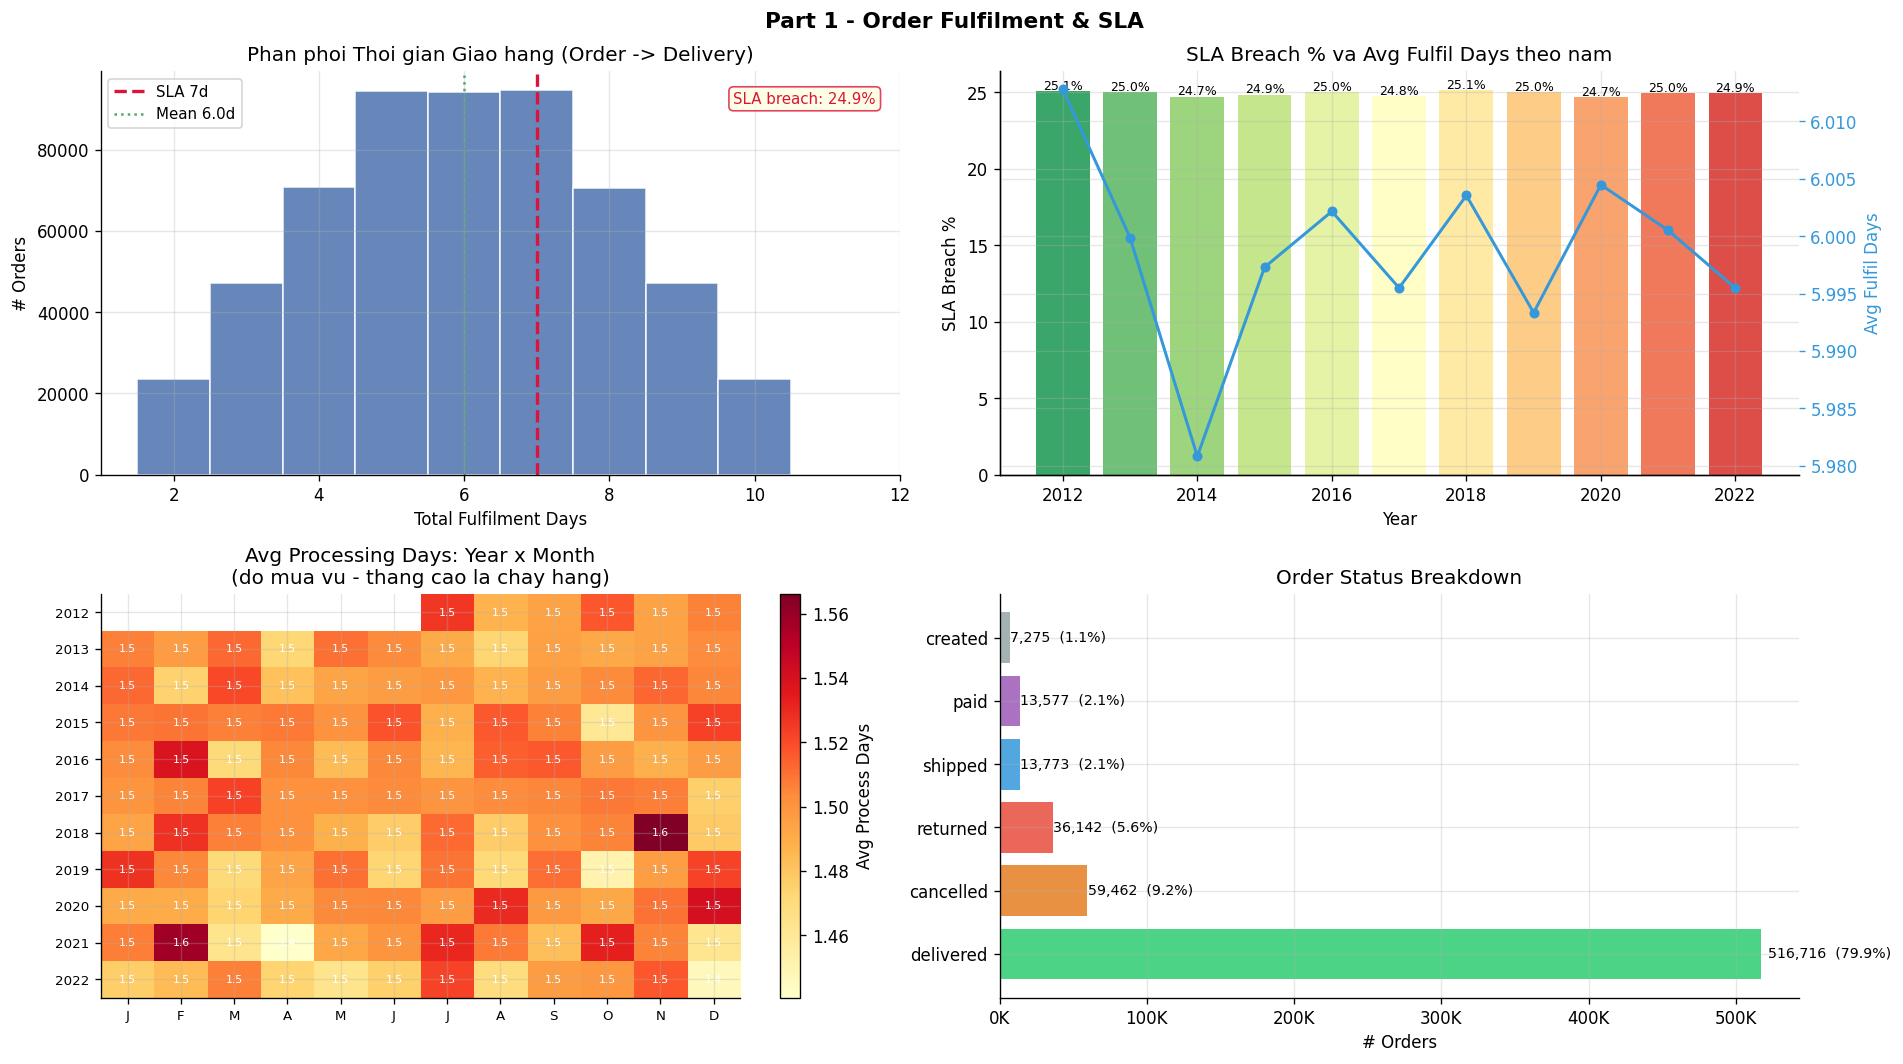

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

# ── A: Fulfilment time distribution ──────────────────────────────────────────
ax = axes[0]
ax.hist(ships_ord['fulfil_days'], bins=range(2,13), color='#4C72B0',
        alpha=0.85, edgecolor='white', align='left')
ax.axvline(SLA_LIMIT, color='crimson', lw=2, linestyle='--', label=f'SLA {SLA_LIMIT}d')
ax.axvline(ships_ord['fulfil_days'].mean(), color='#55A868', lw=1.5,
           linestyle=':', label=f'Mean {ships_ord["fulfil_days"].mean():.1f}d')
ax.set_xlabel('Total Fulfilment Days'); ax.set_ylabel('# Orders')
ax.set_title('Phan phoi Thoi gian Giao hang (Order -> Delivery)')
ax.legend(fontsize=9)
breach_pct = ships_ord['sla_breach'].mean()*100
ax.text(0.97, 0.92, f'SLA breach: {breach_pct:.1f}%',
        transform=ax.transAxes, ha='right', fontsize=9, color='crimson',
        bbox=dict(boxstyle='round', fc='lightyellow', ec='crimson', alpha=0.8))

# ── B: SLA breach % by year ───────────────────────────────────────────────────
ax = axes[1]
colors_yr = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(breach_yr)))
bars = ax.bar(breach_yr['year'], breach_yr['pct_breach'], color=colors_yr, alpha=0.85)
ax_r = ax.twinx()
ax_r.plot(breach_yr['year'], breach_yr['avg_fulfil'], color='#3498db',
          marker='o', lw=1.8, ms=5, label='Avg fulfil days')
ax_r.set_ylabel('Avg Fulfil Days', color='#3498db')
ax_r.tick_params(axis='y', colors='#3498db')
ax.set_xlabel('Year'); ax.set_ylabel('SLA Breach %')
ax.set_title('SLA Breach % va Avg Fulfil Days theo nam')
for bar, val in zip(bars, breach_yr['pct_breach']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}%', ha='center', fontsize=7.5)

# ── C: Processing time by month (heatmap year x month) ───────────────────────
ax = axes[2]
proc_hm = ships_ord.groupby(['year','month'])['process_days'].mean().unstack(fill_value=np.nan)
im = ax.imshow(proc_hm.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(12))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)
ax.set_yticks(range(len(proc_hm.index))); ax.set_yticklabels(proc_hm.index.astype(int), fontsize=8)
plt.colorbar(im, ax=ax, label='Avg Process Days')
for i in range(proc_hm.shape[0]):
    for j in range(proc_hm.shape[1]):
        val = proc_hm.values[i,j]
        if not np.isnan(val):
            ax.text(j,i,f'{val:.1f}',ha='center',va='center',fontsize=6.5,
                    color='white' if val>proc_hm.values[~np.isnan(proc_hm.values)].max()*0.7 else 'black')
ax.set_title('Avg Processing Days: Year x Month\n(do mua vu - thang cao la chay hang)')

# ── D: Order status funnel ────────────────────────────────────────────────────
ax = axes[3]
FUNNEL_COLOR = {'delivered':'#2ecc71','returned':'#e74c3c','cancelled':'#e67e22',
                'shipped':'#3498db','paid':'#9b59b6','created':'#95a5a6'}
for st, cnt in status_cnt.items():
    ax.barh(st, cnt, color=FUNNEL_COLOR.get(st,'#aaa'), alpha=0.85)
    ax.text(cnt*1.01, list(status_cnt.index).index(st),
            f'{cnt:,}  ({status_pct[st]:.1f}%)', va='center', fontsize=8.5)
ax.set_xlabel('# Orders'); ax.set_title('Order Status Breakdown')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e3:.0f}K'))

plt.suptitle('Part 1 - Order Fulfilment & SLA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ops_p1_sla.png', bbox_inches='tight')
plt.show()


## Part 2 · Return Analysis — Noi Margin Bi An Mon
5 return reasons: `late_delivery`, `wrong_size`, `defective`, `changed_mind`, `not_as_described`

In [4]:
total_orders   = orders['order_id'].nunique()
total_returns  = rets['order_id'].nunique()
return_rate    = total_returns / total_orders * 100

# Revenue at risk
total_rev      = order_rev['revenue'].sum()
ret_rev_at_risk = rets_full.merge(order_rev, on='order_id', how='left')['revenue'].sum()

print(f'Return rate            : {return_rate:.2f}%  ({total_returns:,} / {total_orders:,} orders)')
print(f'Total refund amount    : {rets["refund_amount"].sum()/1e9:.3f} B VND')
print(f'Refund / Gross Revenue : {rets["refund_amount"].sum()/total_rev*100:.2f}%')
print(f'Orders: refund > payment: {rets_full["refund_gt_payment"].sum():,}  ({rets_full["refund_gt_payment"].mean()*100:.1f}%)')
print()

# By return reason
reason_stats = rets_full.groupby('return_reason').agg(
    n_returns    = ('return_id',     'count'),
    total_refund = ('refund_amount', 'sum'),
    avg_refund   = ('refund_amount', 'mean'),
    pct_gt_pay   = ('refund_gt_payment','mean'),
).reset_index()
reason_stats['share_pct'] = reason_stats['n_returns'] / len(rets_full) * 100
reason_stats = reason_stats.sort_values('n_returns', ascending=False)
print('=== Return by Reason ===')
print(reason_stats.to_string(index=False))
print()

# By category
cat_stats = rets_full.groupby('category').agg(
    n_returns    = ('return_id',     'count'),
    total_refund = ('refund_amount', 'sum'),
    avg_refund   = ('refund_amount', 'mean'),
).reset_index().sort_values('n_returns', ascending=False)
# Return rate per category (need total orders per category)
cat_orders = (items.merge(prods[['product_id','category']], on='product_id', how='left')
              .groupby('category')['order_id'].nunique().reset_index()
              .rename(columns={'order_id':'n_orders'}))
cat_stats = cat_stats.merge(cat_orders, on='category', how='left')
cat_stats['return_rate_pct'] = cat_stats['n_returns'] / cat_stats['n_orders'] * 100
print('=== Return Rate by Category ===')
print(cat_stats.to_string(index=False))
print()

# Annual return trend
annual_ret = rets_full.groupby('year').agg(
    n_returns    = ('return_id',     'count'),
    total_refund = ('refund_amount', 'sum'),
).reset_index()
annual_ord = orders.groupby(orders['order_date'].dt.year)['order_id'].count().reset_index()
annual_ord.columns = ['year','n_orders']
annual_ret = annual_ret.merge(annual_ord, on='year', how='left')
annual_ret['return_rate_pct'] = annual_ret['n_returns'] / annual_ret['n_orders'] * 100
print('=== Annual Return Rate ===')
print(annual_ret[['year','n_returns','n_orders','return_rate_pct','total_refund']].to_string(index=False))

# Margin erosion: net revenue = gross - refund per year
items_yr = items.merge(orders[['order_id','order_date']], on='order_id', how='left')
items_yr['year'] = items_yr['order_date'].dt.year
items_yr['rev_line'] = items_yr['quantity'] * items_yr['unit_price']
annual_gross = items_yr.groupby('year')['rev_line'].sum().reset_index().rename(columns={'rev_line':'gross_rev'})
annual_ret = annual_ret.merge(annual_gross, on='year', how='left')
annual_ret['margin_erosion_pct'] = annual_ret['total_refund'] / annual_ret['gross_rev'] * 100
print()
print('=== Margin Erosion by Year (refund / gross_rev) ===')
print(annual_ret[['year','gross_rev','total_refund','margin_erosion_pct']].to_string(index=False))


Return rate            : 5.57%  (36,062 / 646,945 orders)
Total refund amount    : 0.511 B VND
Refund / Gross Revenue : 3.11%
Orders: refund > payment: 3,430  (8.6%)

=== Return by Reason ===
   return_reason  n_returns  total_refund   avg_refund  pct_gt_pay  share_pct
      wrong_size      13967  176687200.75 12650.332981    0.084914  34.970831
       defective       8020  103599143.26 12917.598910    0.085411  20.080623
not_as_described       7035   90653190.78 12886.025697    0.084861  17.614362
    changed_mind       6931   89721759.00 12944.994806    0.086279  17.353965
   late_delivery       3986   49937212.76 12528.151721    0.091320   9.980220



=== Return Rate by Category ===
  category  n_returns  total_refund   avg_refund  n_orders  return_rate_pct
Streetwear      21799  406708249.13 18657.197538    389543         5.596045
   Outdoor      14720   78717514.88  5347.657261    200454         7.343331
      GenZ       2126   11145648.17  5242.543824     37054         5.737572
    Casual       1294   14027094.37 10840.103841     23600         5.483051

=== Annual Return Rate ===
 year  n_returns  n_orders  return_rate_pct  total_refund
 2012       2115     32051         6.598858   23609396.67
 2013       4944     76849         6.433395   51996488.43
 2014       5105     80645         6.330213   58245013.52
 2015       5168     82622         6.254993   60567497.04
 2016       5153     82247         6.265274   66336938.53
 2017       4698     76010         6.180766   59012186.53
 2018       4122     69510         5.930082   56219259.06
 2019       2484     41601         5.971010   35130741.54
 2020       2069     34881         5.9

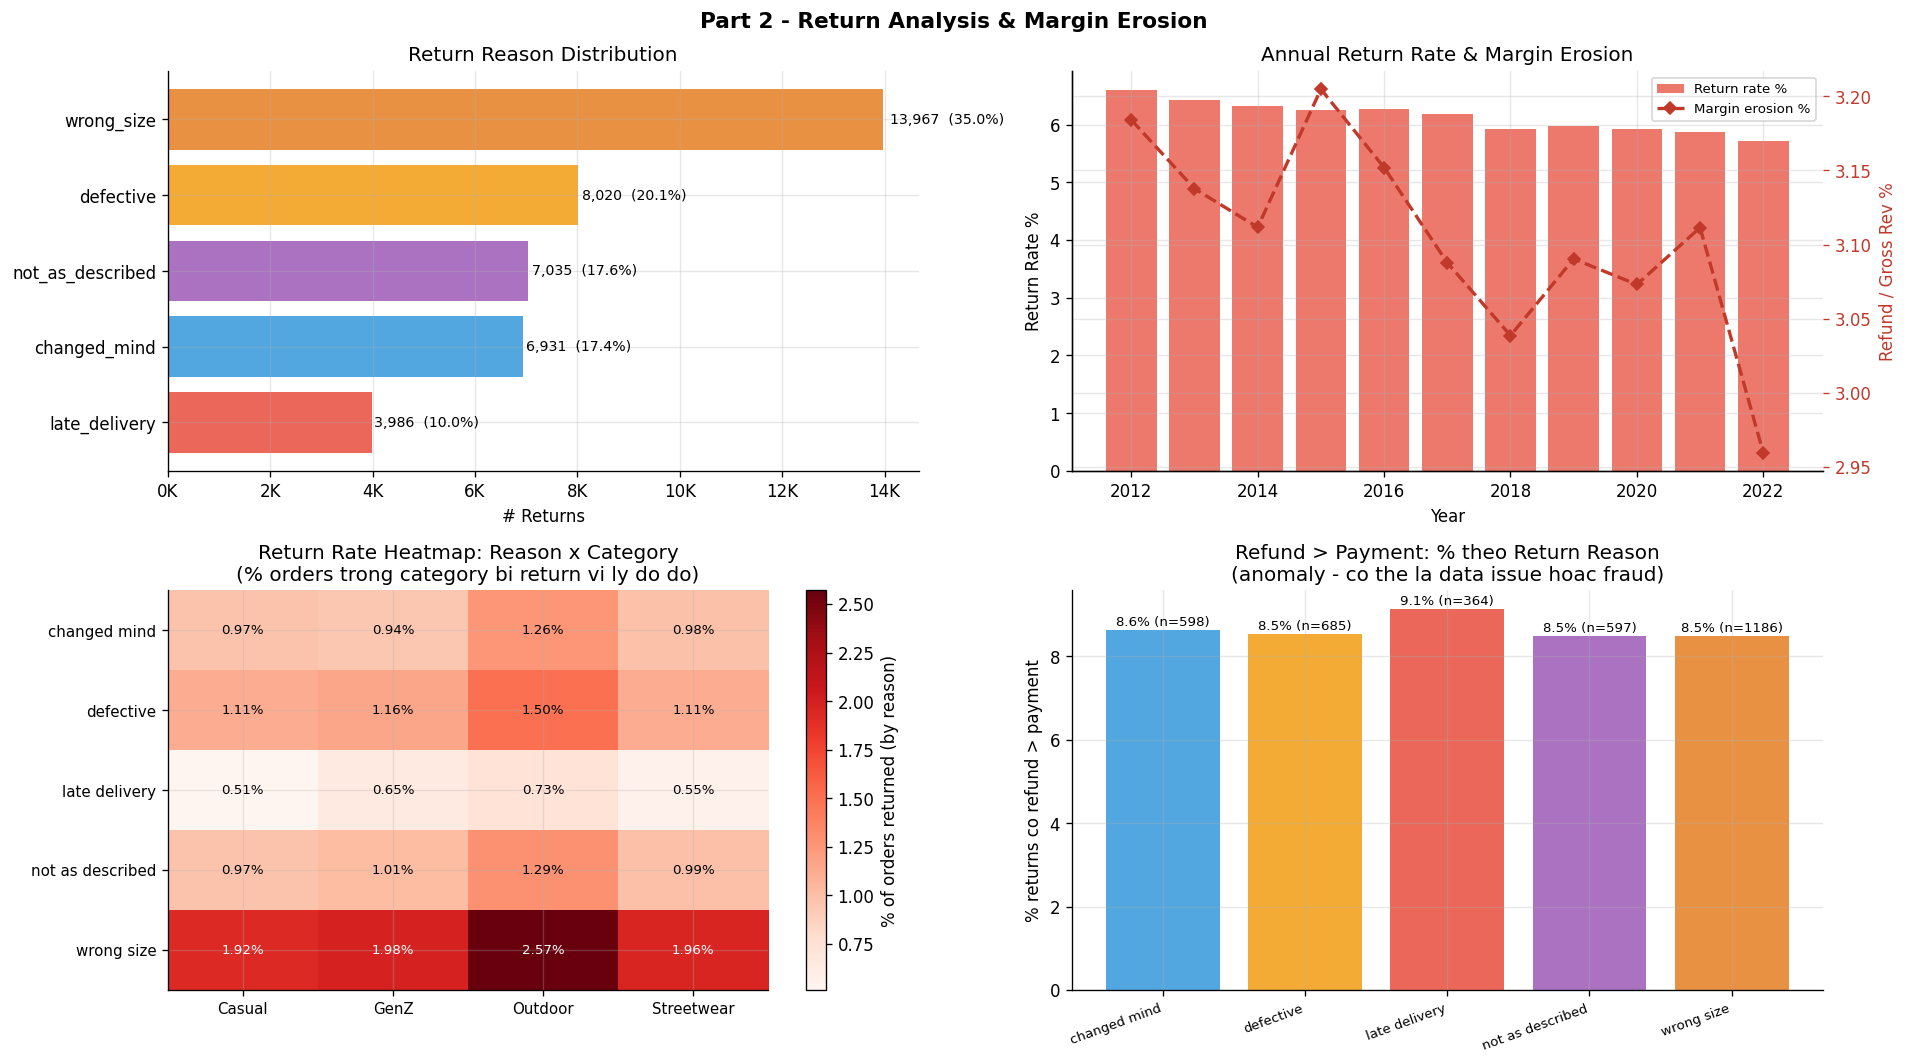

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

REASON_COLORS = {'late_delivery':'#e74c3c','wrong_size':'#e67e22','defective':'#f39c12',
                 'changed_mind':'#3498db','not_as_described':'#9b59b6'}

# ── A: Return reason distribution ────────────────────────────────────────────
ax = axes[0]
r_sorted = reason_stats.sort_values('n_returns', ascending=True)
colors_r = [REASON_COLORS.get(r,'#aaa') for r in r_sorted['return_reason']]
bars = ax.barh(r_sorted['return_reason'], r_sorted['n_returns'], color=colors_r, alpha=0.85)
for bar, row in zip(bars, r_sorted.itertuples()):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{row.n_returns:,}  ({row.share_pct:.1f}%)', va='center', fontsize=8.5)
ax.set_xlabel('# Returns'); ax.set_title('Return Reason Distribution')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e3:.0f}K'))

# ── B: Annual return rate + margin erosion ────────────────────────────────────
ax = axes[1]
ax.bar(annual_ret['year'], annual_ret['return_rate_pct'],
       color='#e74c3c', alpha=0.75, label='Return rate %')
ax2 = ax.twinx()
ax2.plot(annual_ret['year'], annual_ret['margin_erosion_pct'],
         color='#c0392b', marker='D', ms=5, lw=2, linestyle='--', label='Margin erosion %')
ax2.set_ylabel('Refund / Gross Rev %', color='#c0392b')
ax2.tick_params(axis='y', colors='#c0392b')
ax.set_xlabel('Year'); ax.set_ylabel('Return Rate %')
ax.set_title('Annual Return Rate & Margin Erosion')
lines1,labs1 = ax.get_legend_handles_labels()
lines2,labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=8, loc='upper right')

# ── C: Category return rate heatmap (reason x category) ──────────────────────
ax = axes[2]
reason_cat = (rets_full.groupby(['return_reason','category'])['return_id']
              .count().unstack(fill_value=0))
# Normalize by category orders
for cat in reason_cat.columns:
    cat_n = cat_orders[cat_orders['category']==cat]['n_orders'].values
    if len(cat_n): reason_cat[cat] = reason_cat[cat] / cat_n[0] * 100
im = ax.imshow(reason_cat.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(reason_cat.columns)))
ax.set_xticklabels(reason_cat.columns, fontsize=9)
ax.set_yticks(range(len(reason_cat.index)))
ax.set_yticklabels([r.replace('_',' ') for r in reason_cat.index], fontsize=9)
plt.colorbar(im, ax=ax, label='% of orders returned (by reason)')
for i in range(reason_cat.shape[0]):
    for j in range(reason_cat.shape[1]):
        ax.text(j,i,f'{reason_cat.values[i,j]:.2f}%',ha='center',va='center',fontsize=8,
                color='white' if reason_cat.values[i,j]>reason_cat.values.max()*0.6 else 'black')
ax.set_title('Return Rate Heatmap: Reason x Category\n(% orders trong category bi return vi ly do do)')

# ── D: Refund > Payment anomaly ───────────────────────────────────────────────
ax = axes[3]
gt_by_reason = rets_full.groupby('return_reason')['refund_gt_payment'].agg(['sum','mean']).reset_index()
gt_by_reason['mean'] *= 100
colors_gt = [REASON_COLORS.get(r,'#aaa') for r in gt_by_reason['return_reason']]
bars2 = ax.bar(range(len(gt_by_reason)), gt_by_reason['mean'], color=colors_gt, alpha=0.85)
ax.set_xticks(range(len(gt_by_reason)))
ax.set_xticklabels([r.replace('_',' ') for r in gt_by_reason['return_reason']],
                   fontsize=8, rotation=20, ha='right')
ax.set_ylabel('% returns co refund > payment')
ax.set_title('Refund > Payment: % theo Return Reason\n(anomaly - co the la data issue hoac fraud)')
for bar, (_, row) in zip(bars2, gt_by_reason.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{row["mean"]:.1f}% (n={int(row["sum"])})', ha='center', fontsize=8)

plt.suptitle('Part 2 - Return Analysis & Margin Erosion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ops_p2_returns.png', bbox_inches='tight')
plt.show()


## Part 3 · Inventory Health & Stockout vs Rating Correlation
> Hypothesis: san pham co nhieu thang stockout → khach hang dau bui hon → rating thap hon?  
> Two levels: (1) per-product aggregate; (2) per product-month (stockout month vs not)

In [6]:
# ── Stockout stats ───────────────────────────────────────────────────────────
print('=== Inventory Health Summary ===')
print(f'Total snapshots    : {len(inv):,}')
print(f'stockout_flag=1    : {inv["stockout_flag"].sum():,}  ({inv["stockout_flag"].mean()*100:.1f}%)')
print(f'overstock_flag=1   : {inv["overstock_flag"].sum():,}  ({inv["overstock_flag"].mean()*100:.1f}%)')
print(f'Avg fill_rate      : {inv["fill_rate"].mean():.4f}')
print(f'Avg stockout_days  : {inv["stockout_days"].mean():.2f}  (per month)')
print()

# Stockout by category
cat_inv = inv.groupby('category').agg(
    n_snapshots   = ('snapshot_date','count'),
    pct_stockout  = ('stockout_flag','mean'),
    avg_fill_rate = ('fill_rate','mean'),
    avg_stockout_days = ('stockout_days','mean'),
).reset_index()
cat_inv['pct_stockout'] *= 100
print('=== Stockout by Category ===')
print(cat_inv.to_string(index=False))
print()

# Annual stockout trend
annual_inv = inv.groupby('year').agg(
    pct_stockout  = ('stockout_flag','mean'),
    avg_fill_rate = ('fill_rate','mean'),
    avg_dos       = ('days_of_supply','mean'),
).reset_index()
annual_inv['pct_stockout'] *= 100
print('=== Annual Stockout Trend ===')
print(annual_inv.to_string(index=False))
print()

# ── Stockout vs Rating Correlation ───────────────────────────────────────────
# Method: per product, compute avg stockout_flag and avg rating
# Correlation across products (those with both inventory and review data)

prod_stockout = inv.groupby('product_id').agg(
    pct_stockout       = ('stockout_flag','mean'),
    avg_stockout_days  = ('stockout_days','mean'),
    avg_fill_rate      = ('fill_rate','mean'),
    avg_dos            = ('days_of_supply','mean'),
).reset_index()

prod_rating = reviews.groupby('product_id').agg(
    avg_rating  = ('rating','mean'),
    n_reviews   = ('rating','count'),
).reset_index()

prod_merged = prod_stockout.merge(prod_rating, on='product_id', how='inner')
print(f'Products co ca inventory va review data: {len(prod_merged):,}')

# Correlation
corr_stockout_rating  = prod_merged['pct_stockout'].corr(prod_merged['avg_rating'])
corr_fillrate_rating  = prod_merged['avg_fill_rate'].corr(prod_merged['avg_rating'])
corr_dos_rating       = prod_merged['avg_dos'].corr(prod_merged['avg_rating'])
corr_stockdays_rating = prod_merged['avg_stockout_days'].corr(prod_merged['avg_rating'])
print()
print('=== Correlation: Inventory Metrics vs Avg Rating ===')
print(f'  stockout_flag %  vs avg_rating : {corr_stockout_rating:+.4f}')
print(f'  fill_rate        vs avg_rating : {corr_fillrate_rating:+.4f}')
print(f'  days_of_supply   vs avg_rating : {corr_dos_rating:+.4f}')
print(f'  stockout_days    vs avg_rating : {corr_stockdays_rating:+.4f}')
print()

# Month-level: stockout tháng T -> rating tháng T
inv['ym'] = inv['year'].astype(str) + '-' + inv['month'].astype(str).str.zfill(2)
reviews['ym'] = reviews['year'].astype(str) + '-' + reviews['month'].astype(str).str.zfill(2)
monthly_stockout = inv.groupby(['product_id','ym'])['stockout_flag'].mean().reset_index()
monthly_rating   = reviews.groupby(['product_id','ym'])['rating'].mean().reset_index()
monthly_merged   = monthly_stockout.merge(monthly_rating, on=['product_id','ym'], how='inner')
corr_monthly = monthly_merged['stockout_flag'].corr(monthly_merged['rating'])
print(f'Monthly-level correlation (stockout_flag vs rating same month): {corr_monthly:+.4f}')

# Split: rating khi co stockout vs khong stockout (product-month level)
with_stockout    = monthly_merged[monthly_merged['stockout_flag'] >  0]['rating']
without_stockout = monthly_merged[monthly_merged['stockout_flag'] == 0]['rating']
print(f'Avg rating (stockout month)    : {with_stockout.mean():.4f}  (n={len(with_stockout):,})')
print(f'Avg rating (no stockout month) : {without_stockout.mean():.4f}  (n={len(without_stockout):,})')
diff = with_stockout.mean() - without_stockout.mean()
print(f'Difference                     : {diff:+.4f}')
from scipy import stats as sp
t_stat, p_val = sp.ttest_ind(with_stockout, without_stockout)
print(f't-test: t={t_stat:.2f}  p={p_val:.4f}  {"*** significant" if p_val<0.001 else "n.s."}')


=== Inventory Health Summary ===
Total snapshots    : 60,247
stockout_flag=1    : 40,571  (67.3%)
overstock_flag=1   : 45,942  (76.3%)
Avg fill_rate      : 0.9613
Avg stockout_days  : 1.16  (per month)

=== Stockout by Category ===
  category  n_snapshots  pct_stockout  avg_fill_rate  avg_stockout_days
    Casual         3503     66.200400       0.961823           1.145304
      GenZ         4674     68.292683       0.961718           1.148481
   Outdoor        21050     67.349169       0.962705           1.118860
Streetwear        31020     67.321083       0.960248           1.192553

=== Annual Stockout Trend ===
 year  pct_stockout  avg_fill_rate     avg_dos
 2012     68.176447       0.953801  161.109256
 2013     67.845601       0.957917  232.444417
 2014     67.617073       0.959910  458.885830
 2015     67.506812       0.959917  699.497003
 2016     67.892694       0.960419  721.286688
 2017     67.784352       0.960431  831.453238
 2018     66.459220       0.962687  899.598051
 

Monthly-level correlation (stockout_flag vs rating same month): -0.0086
Avg rating (stockout month)    : 3.9291  (n=21,467)
Avg rating (no stockout month) : 3.9452  (n=10,299)
Difference                     : -0.0160


t-test: t=-1.53  p=0.1251  n.s.


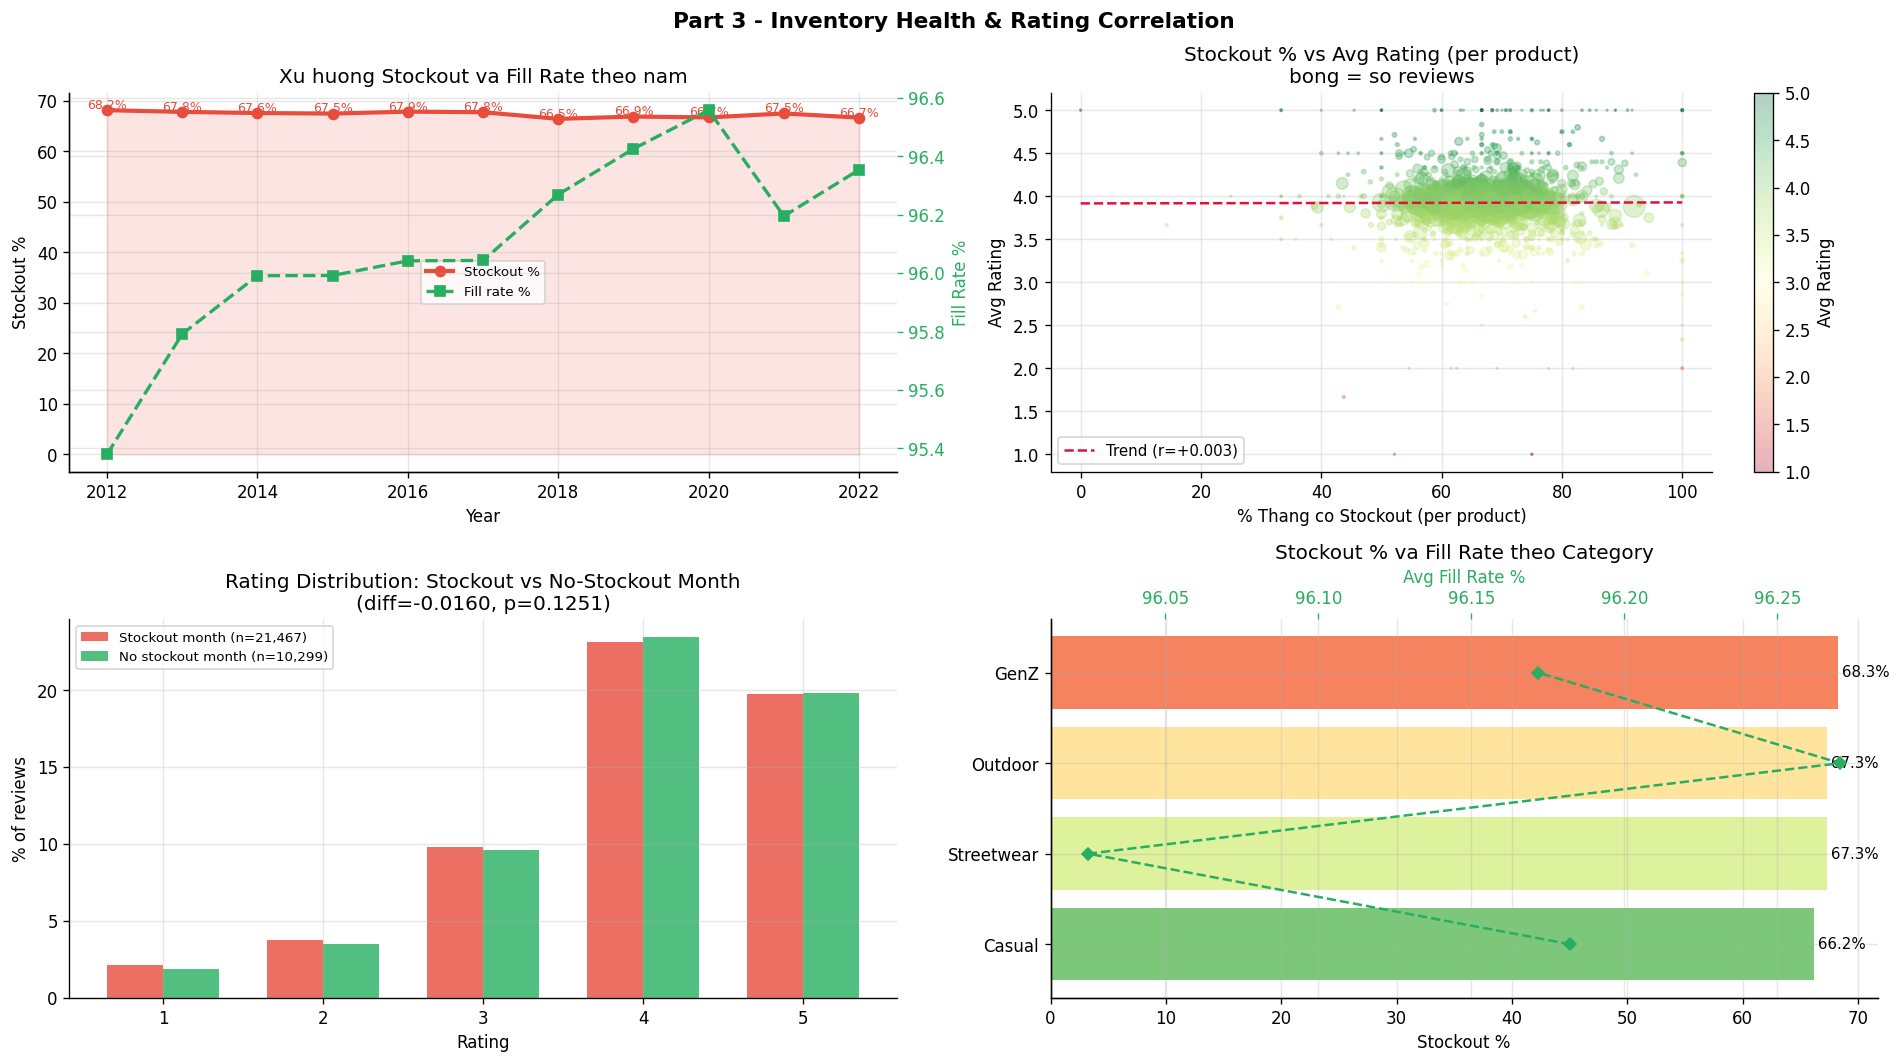

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

# ── A: Annual stockout % trend ────────────────────────────────────────────────
ax = axes[0]
ax.plot(annual_inv['year'], annual_inv['pct_stockout'], marker='o', lw=2.5,
        color='#e74c3c', label='Stockout %')
ax.fill_between(annual_inv['year'], annual_inv['pct_stockout'], alpha=0.15, color='#e74c3c')
ax2 = ax.twinx()
ax2.plot(annual_inv['year'], annual_inv['avg_fill_rate']*100, marker='s', lw=2,
         color='#27ae60', linestyle='--', label='Fill rate %')
ax2.set_ylabel('Fill Rate %', color='#27ae60'); ax2.tick_params(axis='y', colors='#27ae60')
ax.set_ylabel('Stockout %'); ax.set_xlabel('Year')
ax.set_title('Xu huong Stockout va Fill Rate theo nam')
l1,lb1 = ax.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=8)
for x,y in zip(annual_inv['year'], annual_inv['pct_stockout']):
    ax.text(x, y+0.3, f'{y:.1f}%', ha='center', fontsize=7.5, color='#e74c3c')

# ── B: Stockout % vs Avg Rating scatter ──────────────────────────────────────
ax = axes[1]
sc = ax.scatter(prod_merged['pct_stockout']*100, prod_merged['avg_rating'],
                alpha=0.3, s=prod_merged['n_reviews'].clip(1,200),
                c=prod_merged['avg_rating'], cmap='RdYlGn', vmin=1, vmax=5)
# Trend line
z = np.polyfit(prod_merged['pct_stockout']*100, prod_merged['avg_rating'], 1)
xline = np.linspace(0, 100, 100)
ax.plot(xline, np.polyval(z,xline), color='crimson', lw=1.5, linestyle='--',
        label=f'Trend (r={corr_stockout_rating:+.3f})')
ax.set_xlabel('% Thang co Stockout (per product)'); ax.set_ylabel('Avg Rating')
ax.set_title('Stockout % vs Avg Rating (per product)\nbong = so reviews')
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label='Avg Rating')

# ── C: Rating distribution: stockout vs no-stockout months ───────────────────
ax = axes[2]
bins = [0.5,1.5,2.5,3.5,4.5,5.5]
rating_vals = [1,2,3,4,5]
n_so  = len(with_stockout)
n_nso = len(without_stockout)
x = np.arange(5)
w = 0.35
cnt_so  = [(with_stockout==r).sum()/n_so*100 for r in rating_vals]
cnt_nso = [(without_stockout==r).sum()/n_nso*100 for r in rating_vals]
ax.bar(x-w/2, cnt_so,  w, label=f'Stockout month (n={n_so:,})',    color='#e74c3c', alpha=0.8)
ax.bar(x+w/2, cnt_nso, w, label=f'No stockout month (n={n_nso:,})', color='#27ae60', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(['1','2','3','4','5'])
ax.set_xlabel('Rating'); ax.set_ylabel('% of reviews')
ax.set_title(f'Rating Distribution: Stockout vs No-Stockout Month\n'
             f'(diff={with_stockout.mean()-without_stockout.mean():+.4f}, '
             f'p={p_val:.4f})')
ax.legend(fontsize=8)

# ── D: Stockout by category (bar) ─────────────────────────────────────────────
ax = axes[3]
cat_inv_s = cat_inv.sort_values('pct_stockout', ascending=True)
colors_c = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cat_inv_s)))
bars = ax.barh(cat_inv_s['category'], cat_inv_s['pct_stockout'], color=colors_c, alpha=0.85)
ax2b = ax.twiny()
ax2b.plot(cat_inv_s['avg_fill_rate']*100, cat_inv_s['category'],
          color='#27ae60', marker='D', ms=5, lw=1.5, linestyle='--')
ax2b.set_xlabel('Avg Fill Rate %', color='#27ae60'); ax2b.tick_params(axis='x', colors='#27ae60')
ax.set_xlabel('Stockout %'); ax.set_title('Stockout % va Fill Rate theo Category')
for bar, val in zip(bars, cat_inv_s['pct_stockout']):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Part 3 - Inventory Health & Rating Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ops_p3_inventory.png', bbox_inches='tight')
plt.show()


## Part 4 · Customer Satisfaction (Reviews)

In [8]:
print('=== Review Summary ===')
print(f'Total reviews      : {len(reviews):,}')
print(f'Avg rating         : {reviews["rating"].mean():.4f}')
print(f'Rating distribution:')
for r in [1,2,3,4,5]:
    cnt = (reviews['rating']==r).sum()
    pct = cnt/len(reviews)*100
    bar = '|' * int(pct)
    print(f'  {r}★: {cnt:>6,}  ({pct:5.1f}%)  {bar}')
print()

# NPS-like: promoters=5, passives=4, detractors=1-2-3
promoters  = (reviews['rating']==5).sum()
passives   = (reviews['rating']==4).sum()
detractors = (reviews['rating']<=3).sum()
nps_like   = (promoters - detractors) / len(reviews) * 100
print(f'NPS-like score     : {nps_like:.1f}  (promoters {promoters/len(reviews)*100:.1f}% - detractors {detractors/len(reviews)*100:.1f}%)')
print()

# Rating by category
cat_rating = reviews.groupby('category').agg(
    avg_rating  = ('rating','mean'),
    n_reviews   = ('rating','count'),
    pct_5star   = ('rating', lambda x: (x==5).mean()*100),
    pct_1star   = ('rating', lambda x: (x==1).mean()*100),
).reset_index().sort_values('avg_rating', ascending=False)
print('=== Rating by Category ===')
print(cat_rating.to_string(index=False))
print()

# Annual trend
annual_rating = reviews.groupby('year').agg(
    avg_rating  = ('rating','mean'),
    n_reviews   = ('rating','count'),
    pct_5star   = ('rating', lambda x: (x==5).mean()*100),
    pct_1star   = ('rating', lambda x: (x==1).mean()*100),
).reset_index()
print('=== Annual Rating Trend ===')
print(annual_rating.to_string(index=False))
print()

# Reviews per order (coverage)
orders_with_review = reviews['order_id'].nunique()
review_coverage = orders_with_review / len(orders) * 100
print(f'Review coverage: {orders_with_review:,} / {len(orders):,} orders = {review_coverage:.1f}%')
print()

# Top/Bottom products by rating (min 20 reviews)
prod_rat = reviews.groupby('product_id').agg(
    avg_rating = ('rating','mean'), n_reviews = ('rating','count')
).reset_index()
prod_rat = prod_rat[prod_rat['n_reviews'] >= 20]
prod_rat = prod_rat.merge(prods[['product_id','category','segment']], on='product_id', how='left')
print('Bottom 5 products (>=20 reviews):')
print(prod_rat.nsmallest(5,'avg_rating')[['product_id','category','avg_rating','n_reviews']].to_string(index=False))
print()
print('Top 5 products (>=20 reviews):')
print(prod_rat.nlargest(5,'avg_rating')[['product_id','category','avg_rating','n_reviews']].to_string(index=False))


=== Review Summary ===
Total reviews      : 113,551
Avg rating         : 3.9360
Rating distribution:
  1★:  5,772  (  5.1%)  |||||
  2★:  9,095  (  8.0%)  ||||||||
  3★: 17,016  ( 15.0%)  ||||||||||||||
  4★: 36,412  ( 32.1%)  ||||||||||||||||||||||||||||||||
  5★: 45,256  ( 39.9%)  |||||||||||||||||||||||||||||||||||||||

NPS-like score     : 11.8  (promoters 39.9% - detractors 28.1%)

=== Rating by Category ===
  category  avg_rating  n_reviews  pct_5star  pct_1star
Streetwear    3.939398      62704  39.842753   5.033172
   Outdoor    3.933891      41265  39.980613   5.139949
    Casual    3.923219       3790  39.604222   5.382586
      GenZ    3.922825       5792  39.261050   5.024171

=== Annual Rating Trend ===
 year  avg_rating  n_reviews  pct_5star  pct_1star
 2012    3.946505       4879  40.090182   4.898545
 2013    3.934514      13942  40.051643   5.164252
 2014    3.922525      14495  39.751638   5.263884
 2015    3.939463      14834  39.760011   5.042470
 2016    3.930048  

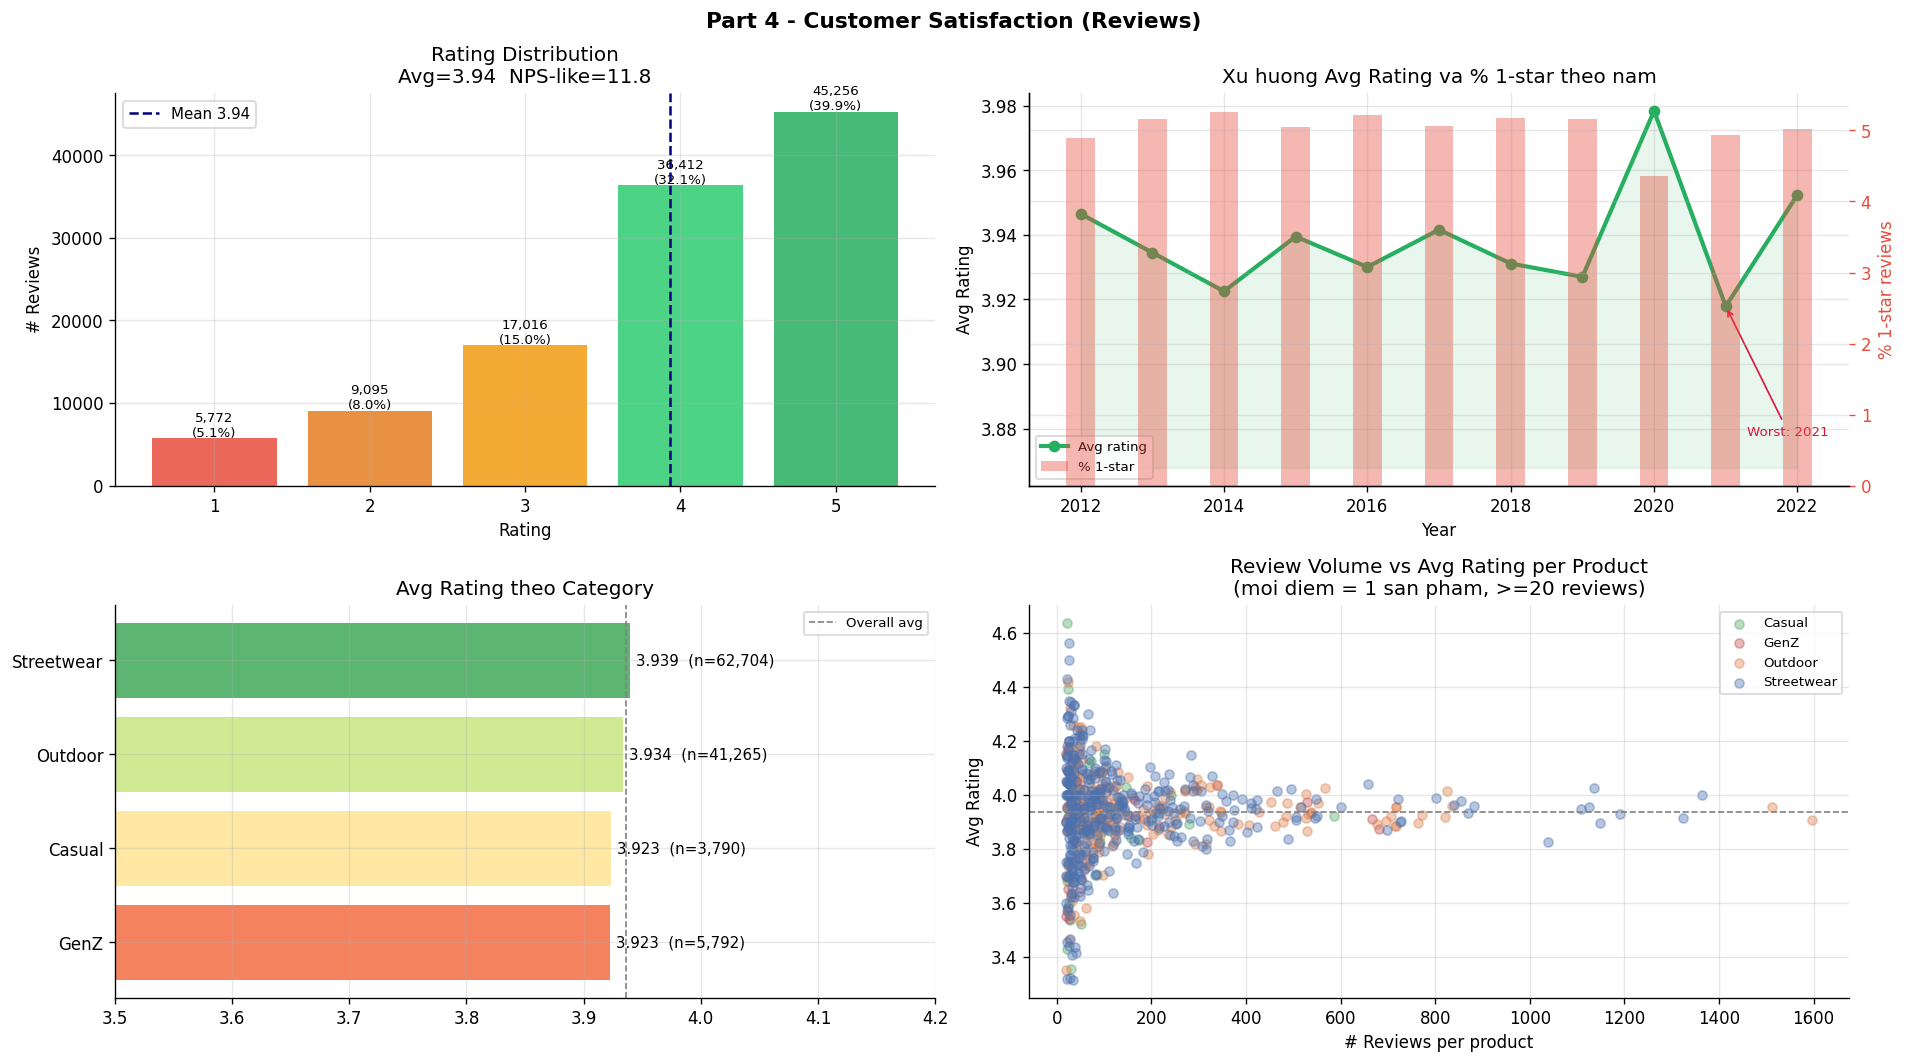

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

# ── A: Rating distribution + NPS ─────────────────────────────────────────────
ax = axes[0]
RATING_COLORS = {1:'#e74c3c',2:'#e67e22',3:'#f39c12',4:'#2ecc71',5:'#27ae60'}
rcnt = [reviews['rating'].eq(r).sum() for r in [1,2,3,4,5]]
bars = ax.bar([1,2,3,4,5], rcnt, color=[RATING_COLORS[r] for r in [1,2,3,4,5]], alpha=0.85)
for bar, cnt in zip(bars, rcnt):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{cnt:,}\n({cnt/len(reviews)*100:.1f}%)', ha='center', fontsize=8)
ax.set_xlabel('Rating'); ax.set_ylabel('# Reviews')
ax.set_title(f'Rating Distribution\nAvg={reviews["rating"].mean():.2f}  NPS-like={nps_like:.1f}')
ax.axvline(reviews['rating'].mean(), color='navy', lw=1.5, linestyle='--',
           label=f'Mean {reviews["rating"].mean():.2f}')
ax.legend(fontsize=9)

# ── B: Annual avg rating trend ────────────────────────────────────────────────
ax = axes[1]
ax.plot(annual_rating['year'], annual_rating['avg_rating'],
        marker='o', lw=2.5, color='#27ae60', label='Avg rating')
ax.fill_between(annual_rating['year'], annual_rating['avg_rating'],
                annual_rating['avg_rating'].min()-0.05, alpha=0.1, color='#27ae60')
ax2 = ax.twinx()
ax2.bar(annual_rating['year'], annual_rating['pct_1star'],
        alpha=0.4, color='#e74c3c', width=0.4, label='% 1-star')
ax2.set_ylabel('% 1-star reviews', color='#e74c3c')
ax2.tick_params(axis='y', colors='#e74c3c')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Rating')
ax.set_title('Xu huong Avg Rating va % 1-star theo nam')
l1,lb1 = ax.get_legend_handles_labels(); l2,lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=8, loc='lower left')
# Anomaly annotation
worst_yr = annual_rating.loc[annual_rating['avg_rating'].idxmin()]
ax.annotate(f'Worst: {int(worst_yr["year"])}',
            xy=(worst_yr['year'], worst_yr['avg_rating']),
            xytext=(worst_yr['year']+0.3, worst_yr['avg_rating']-0.04),
            fontsize=8, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1))

# ── C: Rating by category ─────────────────────────────────────────────────────
ax = axes[2]
cat_r = cat_rating.sort_values('avg_rating', ascending=True)
cat_colors_ = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(cat_r)))
bars2 = ax.barh(cat_r['category'], cat_r['avg_rating'], color=cat_colors_, alpha=0.85)
ax.set_xlim(3.5, 4.2)
ax.axvline(reviews['rating'].mean(), color='grey', lw=1, linestyle='--', label='Overall avg')
for bar, (_, row) in zip(bars2, cat_r.iterrows()):
    ax.text(row['avg_rating']+0.005, bar.get_y()+bar.get_height()/2,
            f'{row["avg_rating"]:.3f}  (n={row["n_reviews"]:,})',
            va='center', fontsize=9)
ax.set_title('Avg Rating theo Category')
ax.legend(fontsize=8)

# ── D: Review volume vs avg rating per product (scatter) ──────────────────────
ax = axes[3]
cat_colors_map = {'Streetwear':'#4C72B0','Outdoor':'#DD8452','Casual':'#55A868','GenZ':'#C44E52'}
for cat, grp in prod_rat.groupby('category'):
    ax.scatter(grp['n_reviews'], grp['avg_rating'],
               alpha=0.4, s=30, label=cat,
               color=cat_colors_map.get(cat,'#aaa'))
ax.axhline(reviews['rating'].mean(), color='grey', lw=1, linestyle='--')
ax.set_xlabel('# Reviews per product'); ax.set_ylabel('Avg Rating')
ax.set_title('Review Volume vs Avg Rating per Product\n(moi diem = 1 san pham, >=20 reviews)')
ax.legend(fontsize=8)

plt.suptitle('Part 4 - Customer Satisfaction (Reviews)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ops_p4_reviews.png', bbox_inches='tight')
plt.show()


## Summary

In [10]:
print('='*65)
print('OPERATIONS & SERVICE QUALITY SUMMARY')
print('='*65)
print()
print('=== Order Fulfilment ===')
print(f'  Delivered rate       : {status_cnt.get("delivered",0)/len(orders)*100:.1f}%')
print(f'  Cancelled rate       : {status_cnt.get("cancelled",0)/len(orders)*100:.1f}%')
print(f'  Avg fulfil time      : {ships_ord["fulfil_days"].mean():.1f} days')
print(f'  SLA breach (>{SLA_LIMIT}d)    : {ships_ord["sla_breach"].mean()*100:.2f}%')
print()
print('=== Return Analysis ===')
print(f'  Return rate          : {return_rate:.2f}%')
print(f'  Total refund         : {rets["refund_amount"].sum()/1e9:.3f} B VND')
print(f'  Refund / Gross Rev   : {rets["refund_amount"].sum()/total_rev*100:.2f}%')
print(f'  Top reason           : {reason_stats.iloc[0]["return_reason"]} ({reason_stats.iloc[0]["share_pct"]:.1f}%)')
print(f'  Refund > payment     : {rets_full["refund_gt_payment"].sum():,} cases ({rets_full["refund_gt_payment"].mean()*100:.1f}%)')
print()
print('=== Inventory Health ===')
print(f'  Avg stockout rate    : {inv["stockout_flag"].mean()*100:.1f}%')
print(f'  Avg fill_rate        : {inv["fill_rate"].mean():.4f}')
print(f'  Stockout vs Rating   : r={corr_stockout_rating:+.4f}  (monthly: {corr_monthly:+.4f})')
print(f'  Rating (stockout mo) : {with_stockout.mean():.4f}  vs  {without_stockout.mean():.4f} (no stockout)  diff={diff:+.4f}')
print()
print('=== Customer Satisfaction ===')
print(f'  Avg rating           : {reviews["rating"].mean():.4f}')
print(f'  NPS-like score       : {nps_like:.1f}')
print(f'  Review coverage      : {review_coverage:.1f}% of orders')
worst_yr_val = annual_rating.loc[annual_rating["avg_rating"].idxmin()]
best_yr_val  = annual_rating.loc[annual_rating["avg_rating"].idxmax()]
print(f'  Best year            : {int(best_yr_val["year"])}  (avg={best_yr_val["avg_rating"]:.3f})')
print(f'  Worst year           : {int(worst_yr_val["year"])} (avg={worst_yr_val["avg_rating"]:.3f})')


OPERATIONS & SERVICE QUALITY SUMMARY

=== Order Fulfilment ===
  Delivered rate       : 79.9%
  Cancelled rate       : 9.2%
  Avg fulfil time      : 6.0 days
  SLA breach (>7d)    : 24.92%

=== Return Analysis ===
  Return rate          : 5.57%
  Total refund         : 0.511 B VND
  Refund / Gross Rev   : 3.11%
  Top reason           : wrong_size (35.0%)
  Refund > payment     : 3,430 cases (8.6%)

=== Inventory Health ===
  Avg stockout rate    : 67.3%
  Avg fill_rate        : 0.9613
  Stockout vs Rating   : r=+0.0029  (monthly: -0.0086)
  Rating (stockout mo) : 3.9291  vs  3.9452 (no stockout)  diff=-0.0160

=== Customer Satisfaction ===
  Avg rating           : 3.9360
  NPS-like score       : 11.8
  Review coverage      : 17.2% of orders
  Best year            : 2020  (avg=3.978)
  Worst year           : 2021 (avg=3.918)
